# Sales Forecasting - Trend & Seasonality Analysis

This notebook analyzes trends, seasonality, and patterns in the sales data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, str(Path('..').resolve()))

from src.time_series_analysis import (
    detect_trend,
    check_stationarity,
    decompose_time_series,
    calculate_seasonal_strength,
    identify_peak_periods,
    calculate_autocorrelation,
)

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Screenshot settings
SCREENSHOTS_DIR = Path('../reports/screenshots')
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)

def save_screenshot(fig, name):
    """Save figure to screenshots directory."""
    filepath = SCREENSHOTS_DIR / f'{name}.png'
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f'Saved: {filepath}')

## 1. Load Processed Data

In [3]:
# Load processed daily sales
df = pd.read_csv('../data/processed/daily_sales_features.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Data shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Data shape: (305, 27)
Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00


,Date,total_sales,transaction_count,quantity_sold,unique_customers,year,month,day,day_of_week,day_of_year,...,total_sales_lag_14,total_sales_lag_28,total_sales_rolling_mean_7,total_sales_rolling_std_7,total_sales_rolling_mean_14,total_sales_rolling_std_14,total_sales_rolling_mean_28,total_sales_rolling_std_28,total_sales_expanding_mean,total_sales_expanding_std
0,2010-12-01,46376.49,121,24215,95,2010,12,1,2,335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46376.4900,NaN
1,2010-12-02,47316.53,137,31142,99,2010,12,2,3,336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46846.5100,664.708659
2,2010-12-03,23921.71,57,11839,50,2010,12,3,4,337,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39204.9100,13243.982425
3,2010-12-05,31771.60,87,16449,75,2010,12,5,6,339,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37346.5825,11434.548732
4,2010-12-06,31215.64,94,16291,82,2010,12,6,0,340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36120.3940,10275.182223


## 2. Trend Detection

In [4]:
# Detect linear trend
x = np.arange(len(df))
y = df['total_sales'].values

trend_result = detect_trend(x, y)

print("TREND ANALYSIS")
print("="*50)
print(f"Direction: {trend_result['direction']}")
print(f"Slope: {trend_result['slope']:.2f} (sales per day)")
print(f"R-squared: {trend_result['r_squared']:.4f}")
print(f"P-value: {trend_result['p_value']:.4f}")
print(f"\nInterpretation: {trend_result['interpretation']}")

TREND ANALYSIS
Direction: increasing
Slope: 81.68 (sales per day)
R-squared: 0.1627
P-value: 0.0000

Interpretation: Sales are increasing (p=0.0000, R²=0.1627)


Saved: ../reports/screenshots/03_trend_analysis.png


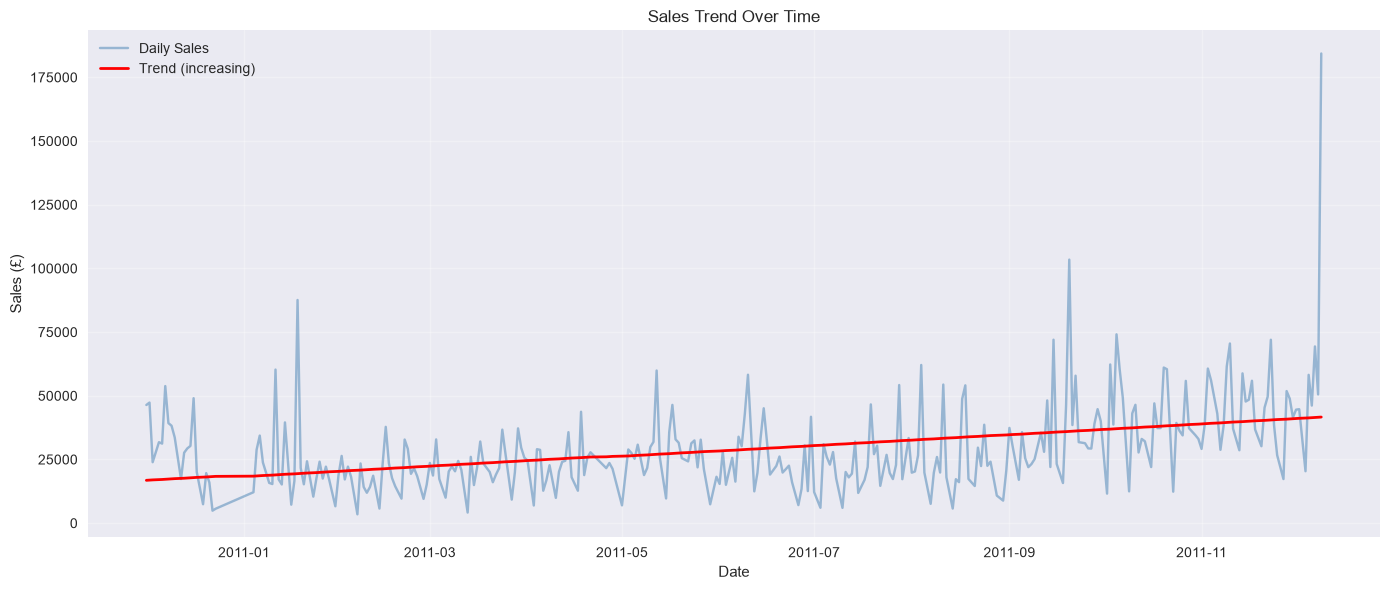

In [5]:
# Plot trend line
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual sales
ax.plot(df['Date'], df['total_sales'], alpha=0.5, label='Daily Sales', color='steelblue')

# Plot trend line
trend_line = trend_result['intercept'] + trend_result['slope'] * x
ax.plot(df['Date'], trend_line, color='red', linewidth=2, label=f'Trend ({trend_result["direction"]})')

ax.set_xlabel('Date')
ax.set_ylabel('Sales (£)')
ax.set_title('Sales Trend Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_screenshot(fig, '03_trend_analysis')
plt.show()

## 3. Stationarity Tests

In [6]:
# Check stationarity
stationarity_result = check_stationarity(df['total_sales'])

print("STATIONARITY TESTS")
print("="*50)
print(f"\nADF Test:")
print(f"  Statistic: {stationarity_result['adf_statistic']:.4f}")
print(f"  P-value: {stationarity_result['adf_p_value']:.4f}")
print(f"  Stationary: {stationarity_result['adf_stationary']}")
print(f"\nKPSS Test:")
print(f"  Statistic: {stationarity_result['kpss_statistic']:.4f}")
print(f"  P-value: {stationarity_result['kpss_p_value']:.4f}")
print(f"  Stationary: {stationarity_result['kpss_stationary']}")
print(f"\nConclusion: {stationarity_result['conclusion']}")

STATIONARITY TESTS

ADF Test:
  Statistic: -0.3661
  P-value: 0.9156
  Stationary: False

KPSS Test:
  Statistic: 1.8996
  P-value: 0.0100
  Stationary: False

Conclusion: Non-stationary


/home/steve/projects/web_portfolio/projects/sales-forecasting/src/time_series_analysis.py:67: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')


## 4. Time Series Decomposition

In [7]:
# Decompose with weekly period (7 days)
decomposition = decompose_time_series(df['total_sales'], period=7)

# Calculate seasonal strength
seasonal_strength = calculate_seasonal_strength(decomposition)
print(f"Seasonal Strength: {seasonal_strength:.4f}")
print(f"(0 = no seasonality, 1 = perfect seasonality)")

Seasonal Strength: 0.0044
(0 = no seasonality, 1 = perfect seasonality)


Saved: ../reports/screenshots/03_time_series_decomposition.png


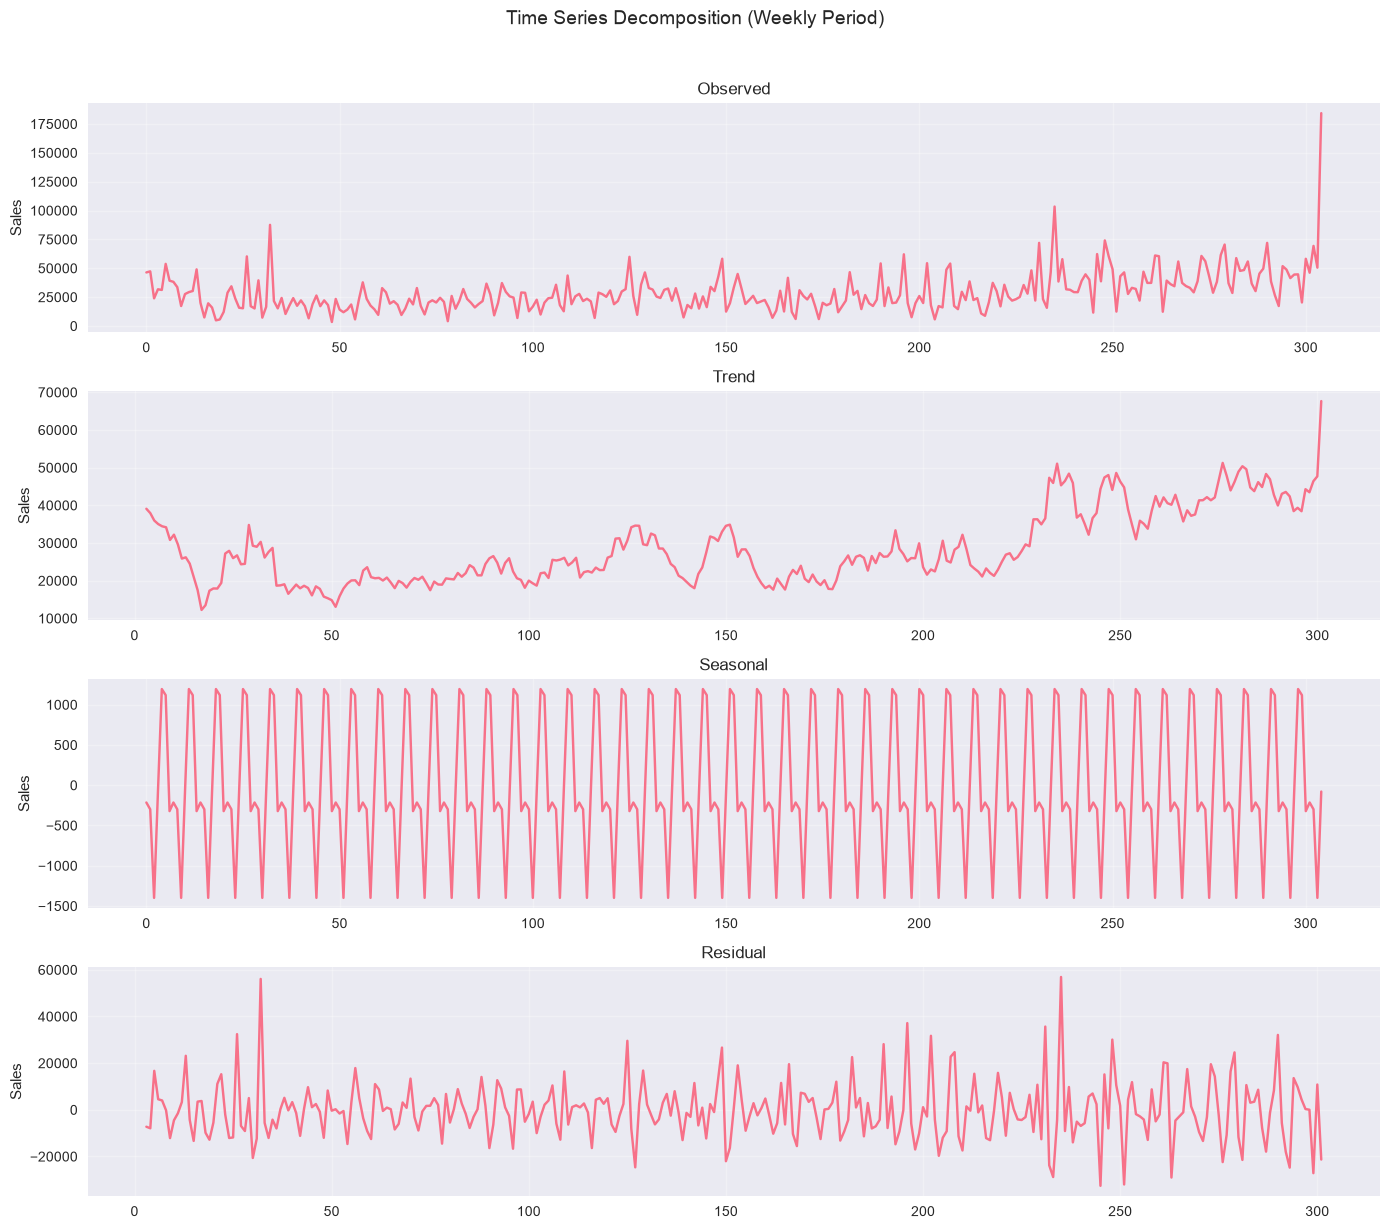

In [8]:
# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Observed
axes[0].plot(decomposition['observed'])
axes[0].set_title('Observed')
axes[0].set_ylabel('Sales')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(decomposition['trend'])
axes[1].set_title('Trend')
axes[1].set_ylabel('Sales')
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(decomposition['seasonal'])
axes[2].set_title('Seasonal')
axes[2].set_ylabel('Sales')
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(decomposition['residual'])
axes[3].set_title('Residual')
axes[3].set_ylabel('Sales')
axes[3].grid(True, alpha=0.3)

plt.suptitle('Time Series Decomposition (Weekly Period)', y=1.02, fontsize=14)
plt.tight_layout()
save_screenshot(fig, '03_time_series_decomposition')
plt.show()

## 5. Seasonal Patterns

In [9]:
# Identify peak periods
peak_periods = identify_peak_periods(df)

print("PEAK PERIODS")
print("="*50)
print(f"Peak Day: {peak_periods['peak_day_of_week']} (avg sales: £{peak_periods['peak_day_sales']:,.2f})")
print(f"Peak Month: {peak_periods['peak_month']} (avg sales: £{peak_periods['peak_month_sales']:,.2f})")

PEAK PERIODS
Peak Day: Thursday (avg sales: £37,299.23)
Peak Month: Nov (avg sales: £44,685.28)


Saved: ../reports/screenshots/03_seasonal_patterns.png


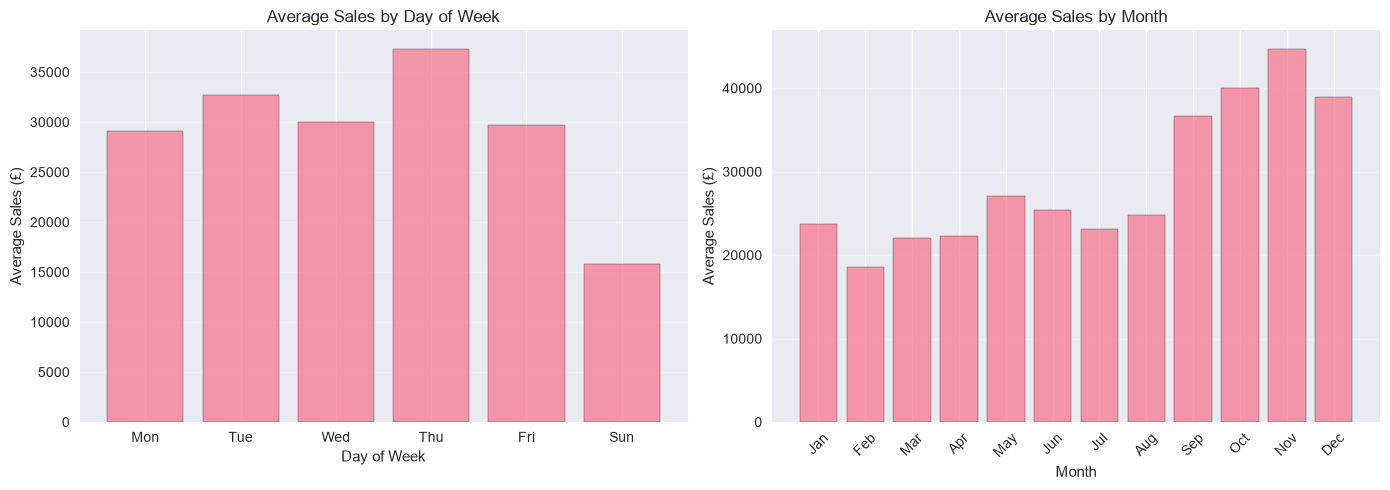

In [10]:
# Plot seasonal patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily pattern (use actual days from data, not hardcoded list)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_data = peak_periods['daily_pattern']
axes[0].bar([day_names[i] for i in daily_data.index], daily_data.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Sales (£)')
axes[0].set_title('Average Sales by Day of Week')
axes[0].grid(True, alpha=0.3, axis='y')

# Monthly pattern
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_data = peak_periods['monthly_pattern']
axes[1].bar([month_names[i-1] for i in monthly_data.index], monthly_data.values, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Sales (£)')
axes[1].set_title('Average Sales by Month')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_screenshot(fig, '03_seasonal_patterns')
plt.show()

## 6. Autocorrelation Analysis

Saved: ../reports/screenshots/03_autocorrelation.png


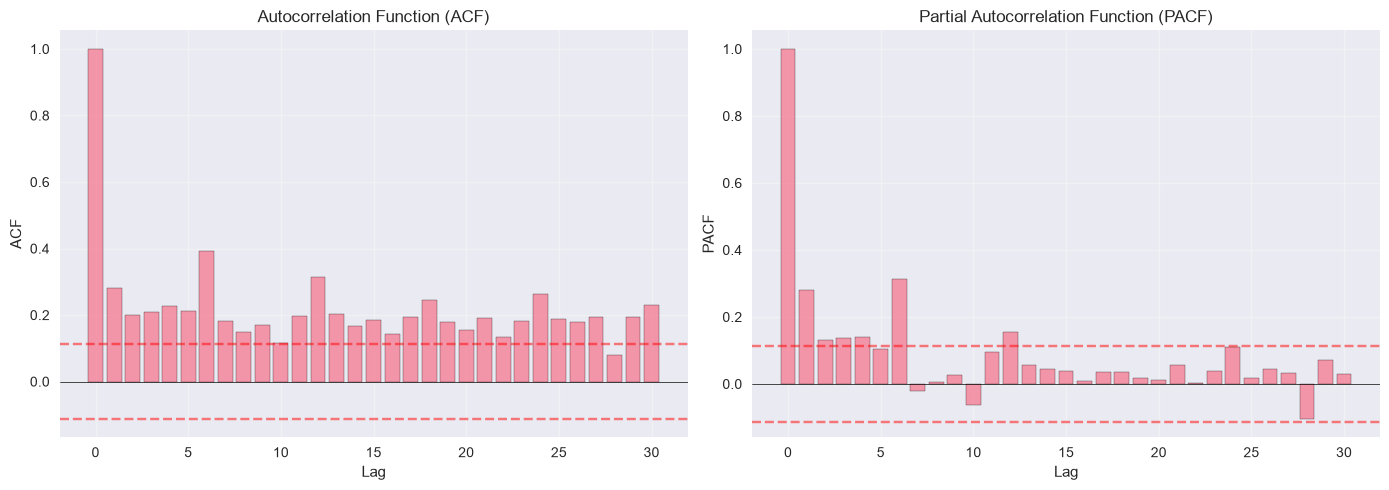

In [11]:
# Calculate autocorrelation
acf_df = calculate_autocorrelation(df['total_sales'], lags=30)

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF
axes[0].bar(acf_df['lag'], acf_df['acf'], edgecolor='black', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].axhline(y=1.96/np.sqrt(len(df)), color='red', linestyle='--', alpha=0.5)
axes[0].axhline(y=-1.96/np.sqrt(len(df)), color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].grid(True, alpha=0.3)

# PACF
axes[1].bar(acf_df['lag'], acf_df['pacf'], edgecolor='black', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].axhline(y=1.96/np.sqrt(len(df)), color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=-1.96/np.sqrt(len(df)), color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('PACF')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_screenshot(fig, '03_autocorrelation')
plt.show()

## 7. Summary

In [12]:
print("="*60)
print("TREND & SEASONALITY ANALYSIS SUMMARY")
print("="*60)
print(f"\n1. TREND")
print(f"   {trend_result['interpretation']}")
print(f"\n2. STATIONARITY")
print(f"   {stationarity_result['conclusion']}")
print(f"\n3. SEASONALITY")
print(f"   Strength: {seasonal_strength:.2%}")
print(f"   Peak Day: {peak_periods['peak_day_of_week']}")
print(f"   Peak Month: {peak_periods['peak_month']}")
print(f"\n4. AUTO-correlation")
print(f"   Lag 7 (weekly) ACF: {acf_df[acf_df['lag']==7]['acf'].values[0]:.4f}")
print("="*60)

TREND & SEASONALITY ANALYSIS SUMMARY

1. TREND
   Sales are increasing (p=0.0000, R²=0.1627)

2. STATIONARITY
   Non-stationary

3. SEASONALITY
   Strength: 0.44%
   Peak Day: Thursday
   Peak Month: Nov

4. AUTO-correlation
   Lag 7 (weekly) ACF: 0.1829
